# EDA: Audio Features (viral vs non-viral)

Dieses Notebook führt eine explorative Datenanalyse (EDA) der bereits extrahierten Audio-Features durch.
Ziel: Vergleiche akustische Merkmale zwischen `top` (viral) und `normal` (nicht-viral) Videos, zeige Verteilungen, Korrelationen und kurze Insights.
Erzeugte Artefakte: Plots werden in `audio_Analyse/plots/` gespeichert, eine zusammenfassende CSV in `features/audio_features_eda_summary.csv` und kurze Notizen in `audio_Analyse/EDA_notes.txt`.

In [1]:
%matplotlib inline
# Imports und Setup
from pathlib import Path
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

# Repo-root detection (kopiert vom Extraktions-Notebook)
def find_repo_root(start: Path = None):
    start = Path.cwd() if start is None else Path(start)
    markers = ['tiktok_100_vs_100', 'requirements.txt', 'README.md', '.git']
    for p in [start] + list(start.parents):
        for m in markers:
            if (p / m).exists():
                return p
    return start

repo_root = find_repo_root()
FEATURES_CSV = repo_root / 'features' / 'audio_features.csv'
OUTPUT_SUMMARY = repo_root / 'features' / 'audio_features_eda_summary.csv'
PLOTS_DIR = repo_root / 'audio_Analyse' / 'plots'
LOG_DIR = repo_root / 'audio_Analyse' / 'logs'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Logger for the EDA
eda_log = LOG_DIR / 'eda.log'
logger = logging.getLogger('audio_features_eda')
logger.setLevel(logging.INFO)
if logger.hasHandlers():
    logger.handlers.clear()
fh = logging.FileHandler(eda_log, mode='a', encoding='utf-8')
fmt = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
fh.setFormatter(fmt)
ch = logging.StreamHandler()
ch.setFormatter(fmt)
logger.addHandler(fh)
logger.addHandler(ch)

logger.info(f'Repo root: {repo_root}')
logger.info(f'Features CSV: {FEATURES_CSV}')
logger.info(f'Plots dir: {PLOTS_DIR}')
logger.info(f'EDA log: {eda_log}')

2025-11-06 10:36:25,025 - INFO - Repo root: c:\Users\CelinaB\Documents\FHDW\Semester 5\Projekt Algorithmen\Viralytics\Viralitaetsanalyse


2025-11-06 10:36:25,026 - INFO - Features CSV: c:\Users\CelinaB\Documents\FHDW\Semester 5\Projekt Algorithmen\Viralytics\Viralitaetsanalyse\features\audio_features.csv


2025-11-06 10:36:25,026 - INFO - Plots dir: c:\Users\CelinaB\Documents\FHDW\Semester 5\Projekt Algorithmen\Viralytics\Viralitaetsanalyse\audio_Analyse\plots


2025-11-06 10:36:25,027 - INFO - EDA log: c:\Users\CelinaB\Documents\FHDW\Semester 5\Projekt Algorithmen\Viralytics\Viralitaetsanalyse\audio_Analyse\logs\eda.log


## Load data and create `group` column
Lade die Datei `features/audio_features.csv` und erstelle eine neue Spalte `group` mit den Werten `top` bzw. `normal` basierend auf `video_id`. Zeige Form, Spalten und Counts pro Gruppe.

In [2]:
# --- Load CSV ---
if not FEATURES_CSV.exists():
    raise FileNotFoundError(f'Features CSV not found: {FEATURES_CSV}')

df = pd.read_csv(FEATURES_CSV)
logger.info(f'Loaded features: {df.shape[0]} rows, {df.shape[1]} columns')

# Create group column: 'top' if video_id starts with 'top' (case-insensitive), else 'normal'
df['video_id'] = df['video_id'].astype(str)
df['group'] = df['video_id'].str.lower().str.startswith('top').map({True: 'top', False: 'normal'})

# Quick checks
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nCounts by group:\n', df['group'].value_counts())
df.head()

2025-11-06 10:36:25,039 - INFO - Loaded features: 197 rows, 21 columns


Shape: (197, 22)

Columns: ['video_id', 'bpm', 'rms_mean', 'rms_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'speech_ratio', 'chroma_var_0', 'chroma_var_1', 'chroma_var_2', 'chroma_var_3', 'chroma_var_4', 'chroma_var_5', 'chroma_var_6', 'chroma_var_7', 'chroma_var_8', 'chroma_var_9', 'chroma_var_10', 'chroma_var_11', 'group']

Counts by group:
 group
top       100
normal     97
Name: count, dtype: int64


,video_id,bpm,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,speech_ratio,chroma_var_0,...,chroma_var_3,chroma_var_4,chroma_var_5,chroma_var_6,chroma_var_7,chroma_var_8,chroma_var_9,chroma_var_10,chroma_var_11,group
0,normal_100_likes_22500_id_7516938565066951991,139.674831,0.014903,0.019588,2816.768409,1743.759460,3153.345758,840.977366,0.908403,0.105630,...,0.091258,0.089877,0.074280,0.078157,0.089455,0.094581,0.088492,0.105486,0.122652,normal
1,normal_10_likes_83700_id_7546779048593181965,67.999589,0.025423,0.015674,4474.662061,1908.788674,4091.647865,722.189966,0.994350,0.104571,...,0.117152,0.135053,0.123853,0.106651,0.107584,0.094656,0.094529,0.088848,0.089647,normal
2,normal_11_likes_30500_id_7559969376590515470,107.666016,0.126814,0.057115,3212.963612,1091.773264,3643.004116,753.319422,0.995717,0.074363,...,0.081846,0.083621,0.081858,0.077154,0.078561,0.078145,0.080191,0.076563,0.079554,normal
3,normal_12_likes_51000_id_7557068031394991415,135.999178,0.044645,0.052302,3050.954201,1684.081678,3179.355446,979.727218,0.955752,0.106044,...,0.112640,0.104974,0.105823,0.096001,0.092091,0.103063,0.114339,0.100204,0.104158,normal
4,normal_13_likes_14100_id_7564088602234309918,126.048018,0.174276,0.115863,3562.231201,1881.436512,3370.279374,736.712843,0.989597,0.116176,...,0.069206,0.059550,0.087237,0.084836,0.079574,0.072699,0.072038,0.076815,0.091000,normal


## Descriptive statistics
Berechne grundlegende Kennzahlen (mean, std, min, max) für alle numerischen Spalten — insgesamt und gruppiert nach `group`. Speichere die gruppierte Zusammenfassung als CSV.

In [3]:
num = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns detected:', num)

# Overall summary
summary_overall = df[num].agg(['mean','std','min','max']).transpose().reset_index().rename(columns={'index':'feature'})
display(summary_overall.head(20))

# Grouped summary
grouped = df.groupby('group')[num].agg(['mean','std','min','max'])
# Flatten MultiIndex columns for readability
grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
grouped = grouped.reset_index()
display(grouped.head())

# Save grouped summary
grouped.to_csv(OUTPUT_SUMMARY, index=False)
logger.info(f'Wrote grouped summary to {OUTPUT_SUMMARY}')

Numeric columns detected: ['bpm', 'rms_mean', 'rms_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'speech_ratio', 'chroma_var_0', 'chroma_var_1', 'chroma_var_2', 'chroma_var_3', 'chroma_var_4', 'chroma_var_5', 'chroma_var_6', 'chroma_var_7', 'chroma_var_8', 'chroma_var_9', 'chroma_var_10', 'chroma_var_11']


,feature,mean,std,min,max
0,bpm,121.701837,28.908322,54.978391,234.907670
1,rms_mean,0.074228,0.057376,0.004348,0.353106
2,rms_std,0.042966,0.030943,0.003344,0.176194
3,spectral_centroid_mean,2565.952100,682.890459,647.105430,4474.662061
4,spectral_centroid_std,1274.502734,399.146491,308.230395,2289.559939
5,spectral_bandwidth_mean,3040.314030,597.678660,1427.543063,4686.635424
6,spectral_bandwidth_std,811.822972,223.180915,328.252982,1710.937006
7,speech_ratio,0.921088,0.128802,0.285167,1.000000
8,chroma_var_0,0.093125,0.019860,0.029905,0.144713
9,chroma_var_1,0.084775,0.021044,0.035754,0.149044


,group,bpm_mean,bpm_std,bpm_min,bpm_max,rms_mean_mean,rms_mean_std,rms_mean_min,rms_mean_max,rms_std_mean,...,chroma_var_9_min,chroma_var_9_max,chroma_var_10_mean,chroma_var_10_std,chroma_var_10_min,chroma_var_10_max,chroma_var_11_mean,chroma_var_11_std,chroma_var_11_min,chroma_var_11_max
0,normal,120.658886,27.832893,54.978391,184.570312,0.080891,0.05492,0.004348,0.285550,0.044558,...,0.034846,0.156412,0.084773,0.021857,0.035380,0.139206,0.084619,0.021814,0.036358,0.143882
1,top,122.713498,30.020074,61.523438,234.907670,0.067765,0.05922,0.004371,0.353106,0.041422,...,0.029363,0.140075,0.083550,0.022803,0.020634,0.143173,0.084812,0.022508,0.029717,0.121593


2025-11-06 10:36:25,086 - INFO - Wrote grouped summary to c:\Users\CelinaB\Documents\FHDW\Semester 5\Projekt Algorithmen\Viralytics\Viralitaetsanalyse\features\audio_features_eda_summary.csv


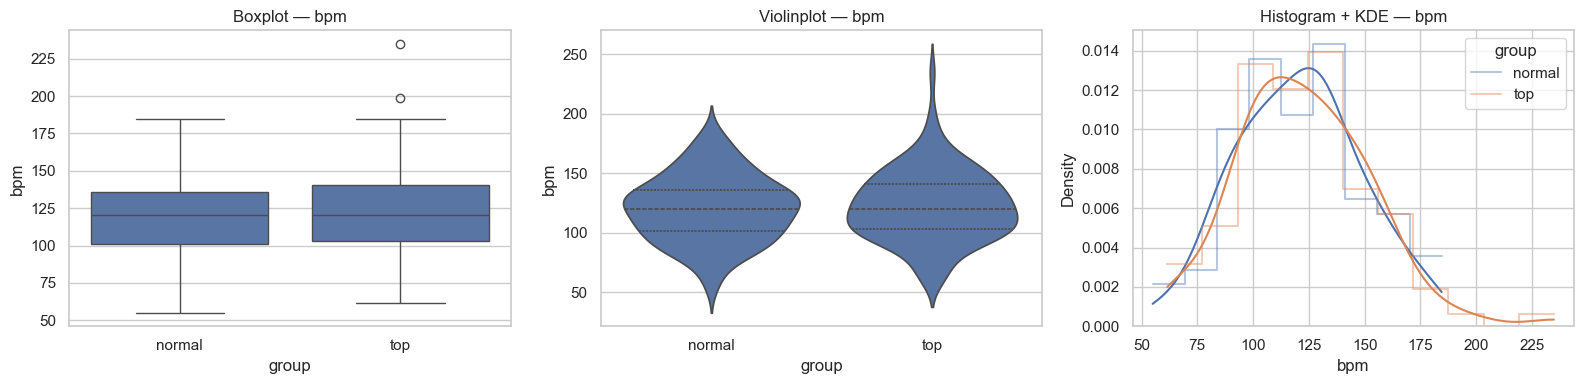

Feature: bpm
  n_top=100, mean_top=122.71, std_top=30.02
  n_norm=97, mean_norm=120.66, std_norm=27.833
  mean_diff (top - normal) = 2.0546
  Cohen's d = 0.071
  Welch t-test: t=0.498, p=0.6188
  Mann-Whitney: stat=4988.0, p=0.7309
  Interpretation: effect: negligible

--------------------------------------------------------------------------------



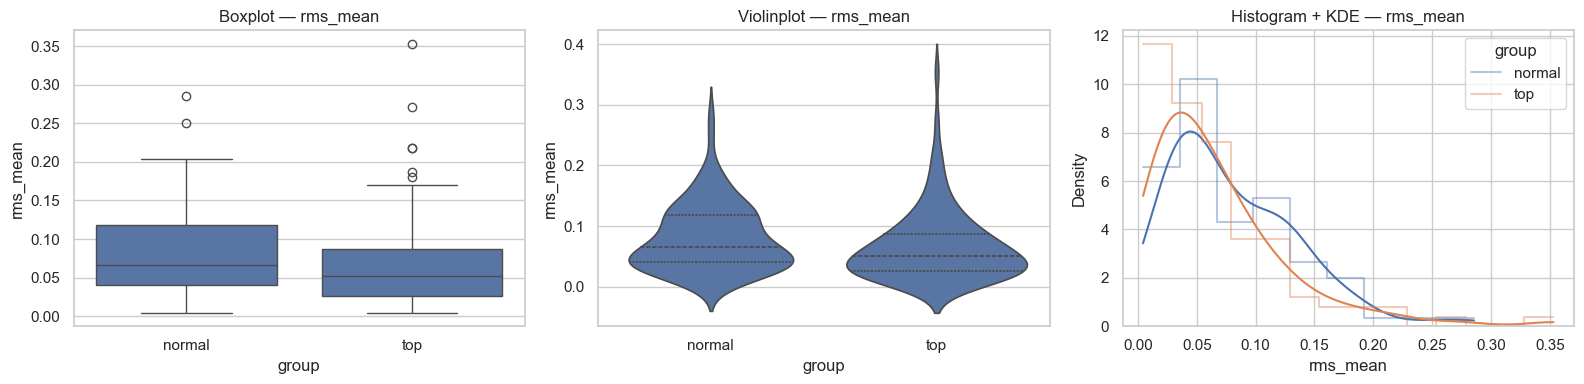

Feature: rms_mean
  n_top=100, mean_top=0.067765, std_top=0.05922
  n_norm=97, mean_norm=0.080891, std_norm=0.05492
  mean_diff (top - normal) = -0.013125
  Cohen's d = -0.230
  Welch t-test: t=-1.614, p=0.1082
  Mann-Whitney: stat=3928.0, p=0.02126
  Interpretation: effect: small; Mann-Whitney: significant (p<0.05)

--------------------------------------------------------------------------------



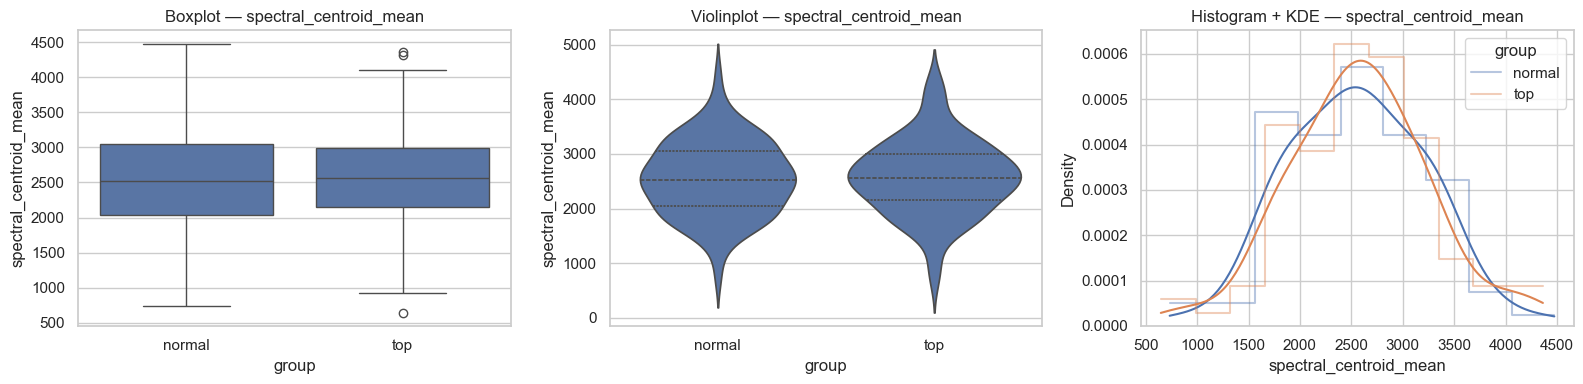

Feature: spectral_centroid_mean
  n_top=100, mean_top=2575.7, std_top=691.54
  n_norm=97, mean_norm=2555.9, std_norm=677.3
  mean_diff (top - normal) = 19.707
  Cohen's d = 0.029
  Welch t-test: t=0.202, p=0.8401
  Mann-Whitney: stat=4929.0, p=0.8444
  Interpretation: effect: negligible

--------------------------------------------------------------------------------



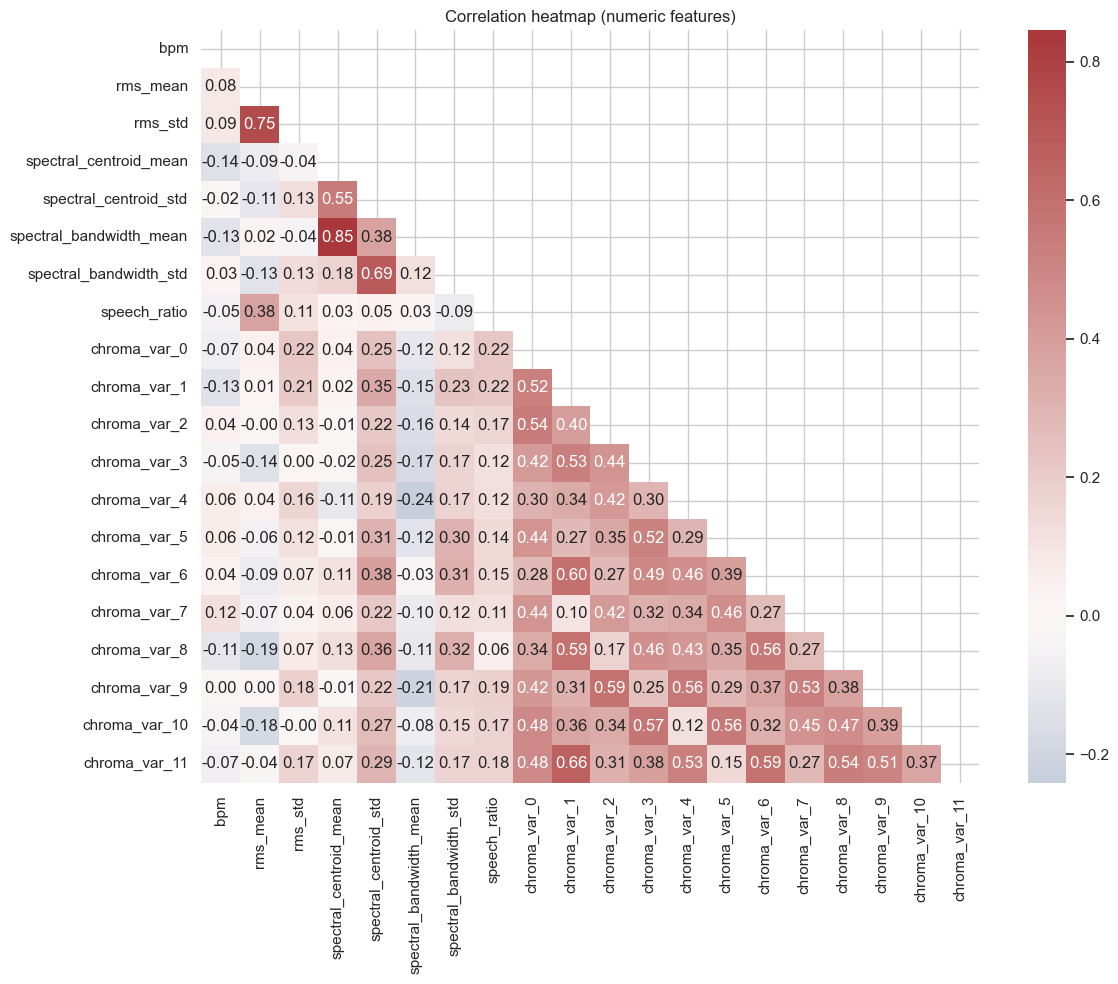

Top correlated feature pairs (by absolute Pearson correlation):
  spectral_centroid_mean <> spectral_bandwidth_mean: abs_corr=0.845
  spectral_bandwidth_mean <> spectral_centroid_mean: abs_corr=0.845
  rms_std <> rms_mean: abs_corr=0.753
  rms_mean <> rms_std: abs_corr=0.753
  spectral_centroid_std <> spectral_bandwidth_std: abs_corr=0.691
  spectral_bandwidth_std <> spectral_centroid_std: abs_corr=0.691
  chroma_var_1 <> chroma_var_11: abs_corr=0.659
  chroma_var_11 <> chroma_var_1: abs_corr=0.659
  chroma_var_1 <> chroma_var_6: abs_corr=0.598
  chroma_var_6 <> chroma_var_1: abs_corr=0.598


In [4]:
# Inline plotting and brief evaluation for central features
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

features_to_plot = ['bpm', 'rms_mean', 'spectral_centroid_mean']

for feat in features_to_plot:
    if feat not in df.columns:
        print(f"Skipping '{feat}': column not found in dataframe")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Boxplot
    sns.boxplot(x='group', y=feat, data=df, ax=axes[0])
    axes[0].set_title(f'Boxplot — {feat}')

    # Violinplot (with quartiles)
    sns.violinplot(x='group', y=feat, data=df, ax=axes[1], inner='quartile')
    axes[1].set_title(f'Violinplot — {feat}')

    # Histogram + KDE overlay
    groups = df['group'].unique()
    for g in groups:
        subset = df.loc[df['group'] == g, feat].dropna()
        if len(subset) > 0:
            sns.histplot(subset, kde=True, stat='density', label=str(g), ax=axes[2], element='step', fill=False, alpha=0.4)
    axes[2].legend(title='group')
    axes[2].set_title(f'Histogram + KDE — {feat}')

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    # Simple numeric comparison and tests
    a = df.loc[df['group'] == 'top', feat].dropna()
    b = df.loc[df['group'] == 'normal', feat].dropna()
    n_top, n_norm = len(a), len(b)
    mean_top, mean_norm = (a.mean() if n_top>0 else np.nan, b.mean() if n_norm>0 else np.nan)
    std_top, std_norm = (a.std(ddof=1) if n_top>1 else np.nan, b.std(ddof=1) if n_norm>1 else np.nan)

    # Cohen's d (pooled)
    cohens_d = np.nan
    if n_top>1 and n_norm>1:
        pooled = np.sqrt(((n_top-1)*(std_top**2) + (n_norm-1)*(std_norm**2)) / (n_top + n_norm - 2))
        cohens_d = (mean_top - mean_norm) / pooled if pooled>0 else np.nan

    # t-test (Welch)
    t_stat, t_p = np.nan, np.nan
    if n_top>0 and n_norm>0:
        try:
            t_stat, t_p = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
        except Exception:
            pass

    # Mann-Whitney
    mw_stat, mw_p = np.nan, np.nan
    try:
        if n_top>0 and n_norm>0:
            mw_stat, mw_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    except Exception:
        pass

    # Print short evaluation
    print(f"Feature: {feat}")
    print(f"  n_top={n_top}, mean_top={mean_top:.5g}, std_top={std_top:.5g}")
    print(f"  n_norm={n_norm}, mean_norm={mean_norm:.5g}, std_norm={std_norm:.5g}")
    print(f"  mean_diff (top - normal) = {mean_top - mean_norm:.5g}")
    print(f"  Cohen's d = {cohens_d:.3f}")
    print(f"  Welch t-test: t={t_stat:.3f}, p={t_p:.4g}")
    print(f"  Mann-Whitney: stat={mw_stat}, p={mw_p:.4g}")
    # Quick interpretation
    interpret = []
    if not np.isnan(cohens_d):
        if abs(cohens_d) < 0.2:
            interpret.append('effect: negligible')
        elif abs(cohens_d) < 0.5:
            interpret.append('effect: small')
        else:
            interpret.append('effect: medium/large')
    if not np.isnan(t_p) and t_p < 0.05:
        interpret.append('t-test: significant (p<0.05)')
    if not np.isnan(mw_p) and mw_p < 0.05:
        interpret.append('Mann-Whitney: significant (p<0.05)')
    if interpret:
        print('  Interpretation:', '; '.join(interpret))
    else:
        print('  Interpretation: no clear effect/significance')
    print('\n' + '-'*80 + '\n')

# Correlation heatmap inline (numeric features)
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric) > 1:
    corr = df[numeric].corr(method='pearson')
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='vlag', center=0)
    plt.title('Correlation heatmap (numeric features)')
    plt.tight_layout()
    display(plt.gcf())
    plt.close()

    # Show top correlated pairs
    corr_unstack = corr.abs().where(~np.eye(len(corr), dtype=bool)).stack().reset_index()
    corr_unstack.columns = ['feat1','feat2','abs_corr']
    top_pairs = corr_unstack.sort_values('abs_corr', ascending=False).head(10)
    print('Top correlated feature pairs (by absolute Pearson correlation):')
    for _, row in top_pairs.iterrows():
        print(f"  {row['feat1']} <> {row['feat2']}: abs_corr={row['abs_corr']:.3f}")
else:
    print('Not enough numeric columns to compute correlation heatmap.')


## Statistische Verfeinerung: Gruppenvergleiche und Mehrfachtest‑Korrektur

In dieser Zelle werden für *alle numerischen Audio‑Features* folgende Kennzahlen berechnet und inline angezeigt:
- Gruppenspezifische Mittelwerte, Standardabweichungen und Stichprobengrößen
- Cohen's d (Effektgröße)
- t‑Test (Welch) und Mann‑Whitney U (nichtparametrisch)
- Benjamini‑Hochberg (FDR) Korrektur für die p‑Werte (getrennt für t‑Test und Mann‑Whitney)

Hinweis: Standardverhalten ist, *keine* CSV zu schreiben; die Ergebnisse erscheinen als Tabelle im Notebook. Wenn du die Ergebnisse trotzdem als CSV speichern möchtest, kann ich das optional hinzufügen.

In [5]:
# Statistical refinement for numeric features: Cohen's d, t-test, Mann-Whitney and BH correction
import numpy as np
import pandas as pd
from scipy import stats

# Identify numeric features (exclude purely identifier-like columns if any)
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
# Optionally exclude index-like or undesired columns
exclude = []  # add names here if you want to exclude specific columns
numeric = [c for c in numeric if c not in exclude]

results = []
for feat in numeric:
    a = df.loc[df['group']=='top', feat].dropna()
    b = df.loc[df['group']=='normal', feat].dropna()
    n_top, n_norm = len(a), len(b)
    mean_top, mean_norm = a.mean() if n_top>0 else np.nan, b.mean() if n_norm>0 else np.nan
    std_top, std_norm = a.std(ddof=1) if n_top>1 else np.nan, b.std(ddof=1) if n_norm>1 else np.nan

    # Cohen's d (pooled)
    cohens_d = np.nan
    try:
        if n_top > 1 and n_norm > 1:
            pooled = np.sqrt(((n_top-1)*(std_top**2) + (n_norm-1)*(std_norm**2)) / (n_top + n_norm - 2))
            cohens_d = (mean_top - mean_norm) / pooled if pooled > 0 else np.nan
    except Exception:
        cohens_d = np.nan

    # t-test (Welch)
    t_stat, t_p = (np.nan, np.nan)
    if n_top > 0 and n_norm > 0:
        try:
            t_stat, t_p = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
        except Exception:
            t_stat, t_p = (np.nan, np.nan)

    # Mann-Whitney
    mw_stat, mw_p = (np.nan, np.nan)
    try:
        if n_top > 0 and n_norm > 0:
            mw_stat, mw_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    except Exception:
        mw_stat, mw_p = (np.nan, np.nan)

    results.append({
        'feature': feat,
        'n_top': n_top,
        'n_norm': n_norm,
        'mean_top': mean_top,
        'mean_norm': mean_norm,
        'std_top': std_top,
        'std_norm': std_norm,
        'cohens_d': cohens_d,
        't_stat': t_stat,
        't_p': t_p,
        'mw_stat': mw_stat,
        'mw_p': mw_p
    })

res_df = pd.DataFrame(results).set_index('feature')

# Benjamini-Hochberg (BH) implementation (fallback, simple)
def bh_adjust(pvals):
    p = np.asarray(pvals).astype(float)
    n = len(p)
    order = np.argsort(p)
    ranked = np.empty(n, dtype=float)
    for i, idx in enumerate(order, start=1):
        ranked[i-1] = p[idx] * n / i
    # enforce monotonicity and cap at 1
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    ranked = np.clip(ranked, 0, 1)
    # map back to original order
    adj = np.empty(n, dtype=float)
    adj[order] = ranked
    return adj

# Apply BH to t_p and mw_p separately
res_df['t_p_adj'] = bh_adjust(res_df['t_p'].fillna(1.0).values)
res_df['mw_p_adj'] = bh_adjust(res_df['mw_p'].fillna(1.0).values)

# Add a column for absolute effect size and a simple flag for small/medium/large
res_df['abs_cohens_d'] = res_df['cohens_d'].abs()
res_df['effect_size_cat'] = pd.cut(res_df['abs_cohens_d'], bins=[-0.01, 0.2, 0.5, 1.0, np.inf], labels=['negligible','small','medium','large'])

# Show sorted results by adjusted t p-value and by abs Cohen's d
from IPython.display import display
print(f"Tested {len(res_df)} numeric features. Showing top results sorted by adjusted t-p (FDR).")
display(res_df.sort_values('t_p_adj').head(30))

print('\nTop features by absolute Cohen\'s d:')
display(res_df.sort_values('abs_cohens_d', ascending=False).head(20))

# End of cell: no CSV saved by default
print("\n(No CSV was written. Enable saving manually if desired.)")

Tested 20 numeric features. Showing top results sorted by adjusted t-p (FDR).


,n_top,n_norm,mean_top,mean_norm,std_top,std_norm,cohens_d,t_stat,t_p,mw_stat,mw_p,t_p_adj,mw_p_adj,abs_cohens_d,effect_size_cat
feature,,,,,,,,,,,,,,,
speech_ratio,100,97,0.902148,0.940614,0.154999,0.091304,-0.301283,-2.129853,0.034701,4191.5,0.099817,0.347014,0.448692,0.301283,small
chroma_var_4,100,97,0.090449,0.083335,0.020832,0.021487,0.336252,2.358369,0.019349,5711.0,0.031483,0.347014,0.314830,0.336252,small
chroma_var_3,100,97,0.088281,0.084453,0.019660,0.019031,0.197766,1.388419,0.166593,5486.0,0.112173,0.606903,0.448692,0.197766,negligible
rms_mean,100,97,0.067765,0.080891,0.059220,0.054920,-0.229690,-1.613598,0.108235,3928.0,0.021257,0.606903,0.314830,0.229690,small
chroma_var_2,100,97,0.088296,0.084702,0.019369,0.018300,0.190682,1.339184,0.182071,5427.0,0.149578,0.606903,0.498592,0.190682,negligible
chroma_var_8,100,97,0.083244,0.078916,0.020582,0.020447,0.210968,1.480512,0.140351,5508.0,0.100281,0.606903,0.448692,0.210968,small
spectral_bandwidth_std,100,97,828.855267,794.263905,227.087874,218.862279,0.155065,1.088710,0.277626,5154.0,0.448073,0.793216,0.993457,0.155065,negligible
spectral_bandwidth_mean,100,97,3053.953340,3026.252885,580.698924,617.398632,0.046241,0.324169,0.746160,4951.0,0.801651,0.932701,0.993457,0.046241,negligible
chroma_var_7,100,97,0.086965,0.085138,0.023752,0.023856,0.076762,0.538604,0.590775,4963.0,0.778552,0.932701,0.993457,0.076762,negligible



Top features by absolute Cohen's d:


,n_top,n_norm,mean_top,mean_norm,std_top,std_norm,cohens_d,t_stat,t_p,mw_stat,mw_p,t_p_adj,mw_p_adj,abs_cohens_d,effect_size_cat
feature,,,,,,,,,,,,,,,
chroma_var_4,100,97,0.090449,0.083335,0.020832,0.021487,0.336252,2.358369,0.019349,5711.0,0.031483,0.347014,0.314830,0.336252,small
speech_ratio,100,97,0.902148,0.940614,0.154999,0.091304,-0.301283,-2.129853,0.034701,4191.5,0.099817,0.347014,0.448692,0.301283,small
rms_mean,100,97,0.067765,0.080891,0.059220,0.054920,-0.229690,-1.613598,0.108235,3928.0,0.021257,0.606903,0.314830,0.229690,small
chroma_var_8,100,97,0.083244,0.078916,0.020582,0.020447,0.210968,1.480512,0.140351,5508.0,0.100281,0.606903,0.448692,0.210968,small
chroma_var_3,100,97,0.088281,0.084453,0.019660,0.019031,0.197766,1.388419,0.166593,5486.0,0.112173,0.606903,0.448692,0.197766,negligible
chroma_var_2,100,97,0.088296,0.084702,0.019369,0.018300,0.190682,1.339184,0.182071,5427.0,0.149578,0.606903,0.498592,0.190682,negligible
spectral_bandwidth_std,100,97,828.855267,794.263905,227.087874,218.862279,0.155065,1.088710,0.277626,5154.0,0.448073,0.793216,0.993457,0.155065,negligible
rms_std,100,97,0.041422,0.044558,0.033011,0.028740,-0.101225,-0.711796,0.477452,4319.0,0.184826,0.932701,0.528073,0.101225,negligible
chroma_var_7,100,97,0.086965,0.085138,0.023752,0.023856,0.076762,0.538604,0.590775,4963.0,0.778552,0.932701,0.993457,0.076762,negligible



(No CSV was written. Enable saving manually if desired.)
